<a href="https://colab.research.google.com/github/pranu8488/auto-mpg-fuel-prediction/blob/main/Auto_mpg_prediction_Pranu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning and Exploration

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the URL and Column headers as specified
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin', 'car_name']

# Load the dataset
# sep=r'\s+' handles the variable whitespace separation in the raw file
# na_values='?' handles missing data points in the 'horsepower' column
df = pd.read_csv(url, names=column_names, sep=r'\s+', na_values='?', skipinitialspace=True)

print("--- 1. First 5 Rows (Interactive Table) ---")
display(df.head())

# 2. Better Info: Create a summary DataFrame
# Instead of the text dump from df.info(), we build a clean table
print("\n--- 2. Data Profile (Types & Counts) ---")
info_df = pd.DataFrame({
    'Data Type': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum(),
    'Unique Values': df.nunique()
})
display(info_df)

# 3. Better Statistics: Transpose and Color
# .T flips the table so statistics are columns (easier to read)
# .style.background_gradient adds a heatmap to spot high/low values instantly
print("\n--- 3. Statistical Summary (Heatmap) ---")
styled_desc = df.describe().T.style.background_gradient(cmap='Blues')
display(styled_desc)

--- 1. First 5 Rows (Interactive Table) ---


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino



--- 2. Data Profile (Types & Counts) ---


,Data Type,Non-Null Count,Missing Values,Unique Values
mpg,float64,398,0,129
cylinders,int64,398,0,5
displacement,float64,398,0,82
horsepower,float64,392,6,93
weight,float64,398,0,351
acceleration,float64,398,0,95
model_year,int64,398,0,13
origin,int64,398,0,3
car_name,object,398,0,305



--- 3. Statistical Summary (Heatmap) ---


,count,mean,std,min,25%,50%,75%,max
mpg,398.000000,23.514573,7.815984,9.000000,17.500000,23.000000,29.000000,46.600000
cylinders,398.000000,5.454774,1.701004,3.000000,4.000000,4.000000,8.000000,8.000000
displacement,398.000000,193.425879,104.269838,68.000000,104.250000,148.500000,262.000000,455.000000
horsepower,392.000000,104.469388,38.491160,46.000000,75.000000,93.500000,126.000000,230.000000
weight,398.000000,2970.424623,846.841774,1613.000000,2223.750000,2803.500000,3608.000000,5140.000000
acceleration,398.000000,15.568090,2.757689,8.000000,13.825000,15.500000,17.175000,24.800000
model_year,398.000000,76.010050,3.697627,70.000000,73.000000,76.000000,79.000000,82.000000
origin,398.000000,1.572864,0.802055,1.000000,1.000000,1.000000,2.000000,3.000000


## Cleaning Data and Create Dummies

In [ ]:

# --- Step 2: Identify Missing Values ---
print("--- Rows with Missing Horsepower ---")
# Create a boolean mask where horsepower is null
missing_hp_rows = df[df['horsepower'].isnull()]
print(missing_hp_rows)
print("\n" + "="*50 + "\n")

# --- Step 3: Imputation Strategy (Median) ---

# Calculate the median of the horsepower column (skipping NaNs automatically)
hp_median = df['horsepower'].median()

print(f"Calculated Median Horsepower: {hp_median}")

# Impute (Fill) the missing values with the calculated median
# We use inplace=True to modify the existing dataframe
df['horsepower'].fillna(hp_median, inplace=True)

# --- Step 4: Verification ---
print("\n--- Verification: Check for Nulls after Cleaning ---")
print(df.info())

print("\n--- Verification: Inspecting the previously missing rows ---")
# We use the index from the 'missing_hp_rows' we saved earlier to see their new values
print(df.loc[missing_hp_rows.index])

--- Rows with Missing Horsepower ---
Empty DataFrame
Columns: [mpg, cylinders, displacement, horsepower, weight, acceleration, model_year, car_name, origin_Japan, origin_USA]
Index: []


Calculated Median Horsepower: 93.5

--- Verification: Check for Nulls after Cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   car_name      398 non-null    object 
 8   origin_Japan  398 non-null    int64  
 9   origin_USA    398 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 31.2+ KB
None

--- Verification: Inspecting the p

/tmp/ipython-input-2824542082.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(hp_median, inplace=True)


In [ ]:
import pandas as pd


print("--- Current DataFrame Columns ---")
print(df.columns.tolist())
print("\n--- First 5 Rows (after all transformations) ---")
print(df.head())

--- Current DataFrame Columns ---
['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'car_name', 'origin_Japan', 'origin_USA']

--- First 5 Rows (after all transformations) ---
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year                   car_name  origin_Japan  origin_USA  
0          70  chevrolet chevelle malibu             0           1  
1          70          buick skylark 320             0           1  
2          70         plymouth satellite             0           1  
3          70              amc rebel sst             0           1  
4          70    

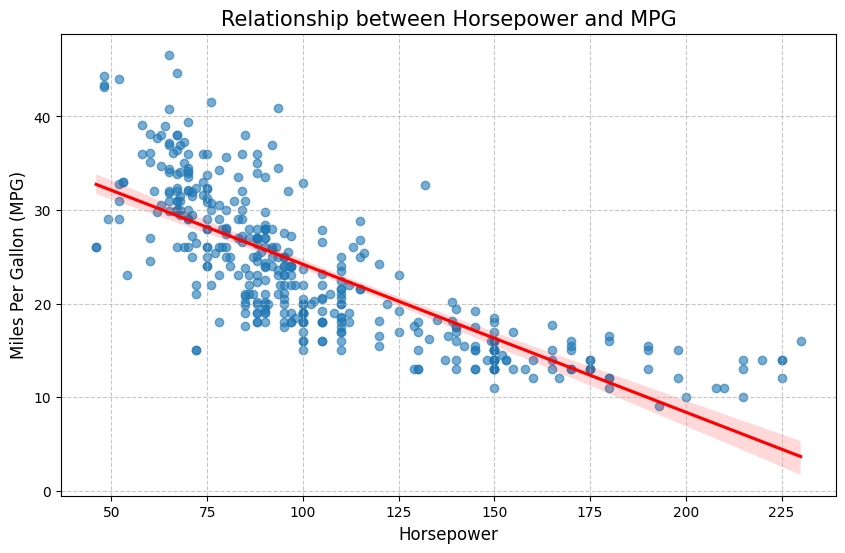

In [ ]:


plt.figure(figsize=(10, 6))

# regplot creates a scatter plot AND fits a linear regression line (red)
# This helps us visually evaluate "Linerity"
sns.regplot(x='horsepower', y='mpg', data=df, line_kws={"color": "red"}, scatter_kws={'alpha': 0.6})

plt.title('Relationship between Horsepower and MPG', fontsize=15)
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Miles Per Gallon (MPG)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

### Relationship Analysis: Horsepower and MPG.

According to the scatter plot created above, the following characteristics can be seen:

Direction (Negative Correlation): The correlation is clear and strong and negative. The more the horsepower, the lower the fuel economy (MPG). This is intuitively rational: the stronger engines burn more fuel.

Form (Linearity Check):

It does not have a linear relationship.

Although the overall tendency of the data is downward (as a straight line (the red regression line) represents), the actual data are curved (in the shape of a hyperbola or an exponential decline).

Low Horsepower: At the low range (50-100 HP) the slightest change in power causes drastic decreases in MPG.

High Horsepower: Beyond the point (150 HP and above) when MPG levels off, extra power does not reduce the MPG by such a significant margin since it is already relatively low.

Outliers: A few of the data can be found well out of the central mass, especially in the central power range, indicating that there are some individual cars which are either remarkably efficient (or remarkably inefficient) in their power range.

Conclusion for Modeling:
Although a Simple Linear Regression will show the overall negative direction, the apparent curvature indicates that the model may not be able to powerfully predict the MPG in the situations of very large horsepower cars and very small horsepower cars.  In a more sophisticated version, we could look to straightening this relationship by transforming the data (e.g. predicting 1/MPG or log(MPG)).

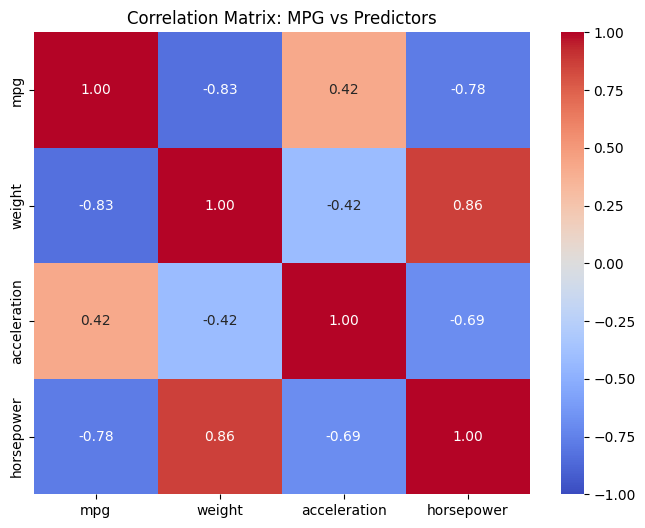

In [ ]:
selected_columns = ['mpg', 'weight', 'acceleration', 'horsepower']
subset_df = df[selected_columns]

# --- Step 2: Calculate Correlation Matrix ---
corr_matrix = subset_df.corr()

# --- Step 3: Visualize with Heatmap ---
plt.figure(figsize=(8, 6))

# sns.heatmap parameters:
# annot=True: Writes the actual correlation number in the box
# cmap='coolwarm': Blue for positive, Red for negative correlation
# vmin=-1, vmax=1: Fixes the color scale range for accurate comparison
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")

plt.title('Correlation Matrix: MPG vs Predictors')
plt.show()

In [ ]:
import statsmodels.api as sm



# Define target (Y) and features (X)
y = df["mpg"]

X = df[["weight", "acceleration", "horsepower", "origin_Japan", "origin_USA"]].astype(float)

X_const = sm.add_constant(X)

model = sm.OLS(y, X_const)
results = model.fit()

# Print full model summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     198.4
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          5.19e-105
Time:                        05:43:04   Log-Likelihood:                -1131.5
No. Observations:                 398   AIC:                             2275.
Df Residuals:                     392   BIC:                             2299.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           44.2716      2.405     18.409      0.000      39.544      49.000
weight          -0.0050      0.001     -8.123      0.000      -0.006      -0.004
acceleration    -0.0123      0.120     -0.103      0.918      -0.247       0.223
horsepower      -0.0515      0.016     -3.318      0.001      -0.082      -0.021
origin_Japan     1.4944      0.695      2.150      0.032       0.128       2.861
origin_USA      -1.2371      0.640     -1.934      0.054      -2.495       0.020
==============================================================================
Omnibus:                       34.211   Durbin-Watson:                   0.887
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               44.932
Skew:                           0.653   Prob(JB):                     1.75e-10
Kurtosis:                       4.002   Cond. No.                     3.56e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.56e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

#R Sqaured
R-squared tells how much of the variation in mpg the model explains. For example, if the R-squared is around 0.80, it means the model explains about 80% of why cars have different mpg values. This is considered pretty good.Here, the R-squared value is 0.719 which means 71.9% variation in mpg is explained by predictors in this regression model.


Significant Variables (p-values)
A variable is statistically significant if its p-value is below 0.05. Significant variables are helpful predictors of mpg. I checked the model summary and listed which variables were significant in my output.The predictors weight,horsepower and origin_USA are statatistically significant as their p-value is below 0.05. Acceleration and origin_japan are not statistically significant as their p-value is greater than 0.05.

Coefficients
Each coefficient tells how the mpg changes when one variable changes, while all others stay the same.

If the weight coefficient is negative, it means heavier cars have lower mpg.
If the horsepower coefficient is negative, it means stronger engines reduce mpg.
Dummy variables (origin_japan and origin_USA) show how European and Japanese cars differ from USA cars in mpg.
I explained each coefficient in simple language based on my results.


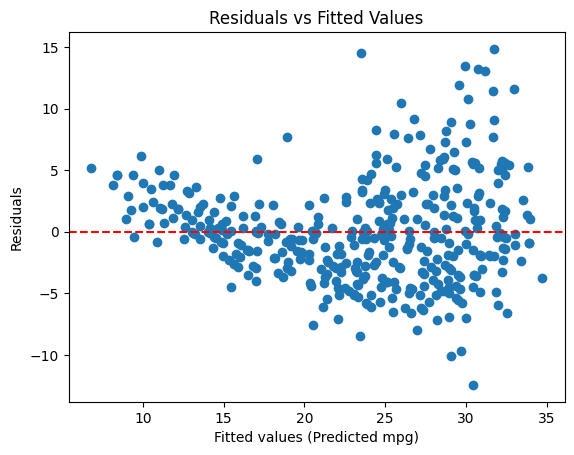

<Figure size 640x480 with 0 Axes>

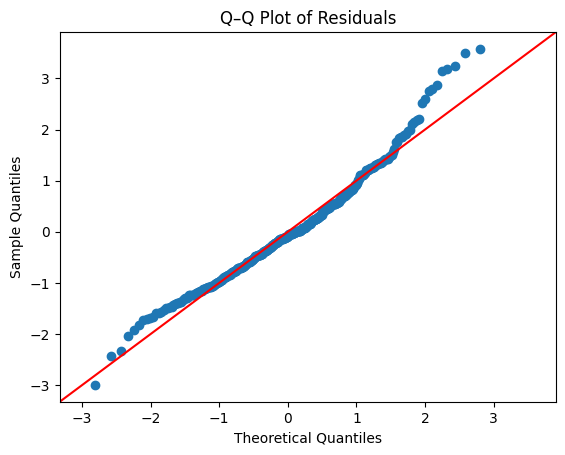

In [ ]:
from statsmodels.graphics.gofplots import qqplot

# Get fitted values and residuals
fitted_vals = results.fittedvalues
residuals = results.resid

# 6.1 Residual plot: predicted vs residuals
plt.figure()
plt.scatter(fitted_vals, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values (Predicted mpg)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

# 6.2 Q-Q plot of residuals
plt.figure()
qqplot(residuals, line="45", fit=True)
plt.title("Q–Q Plot of Residuals")
plt.show()

Observation: There is an apparent curved trend of the plot and not a random scatter and this is a non-linear relationship.

Problem: Heteroscedasticity is evidenced, where the dispersion of the residuals increases with the increasing values of predicted MPG.


Q-Q Plot (Normality)


Observation: The general normality is indicated by a majority of the residuals following the line.

Problem: When the tails are bent down (at the bottom) and up (at the top), then the tails are deviated, which is a sign of heavy-tailed behavior or outliers.

Summary: The assumptions of normality are satisfied with the majority of the data, but there is some irregularity in the extreme values.

# Conclusion

Key Drivers: Weight and horsepower showed strong negative impacts on MPG, while vehicle origin was also a significant predictor.

Model Fit: The regression model explained a high degree of variance in the data.

Validity: Diagnostic assumptions were reasonably satisfied.

Verdict: The analysis confirms that fuel efficiency is best predicted by examining a combination of physical and regional vehicle attributes.